In [1]:
# Importo pandas per analisi su dataframe
import pandas as pd

# Importo libreria matplotlib per la creazione di grafici
import matplotlib.pyplot as plt

# Importo l'algoritmo KMeans dalla libreria sklearn per effettuare il clustering degli utenti
from sklearn.cluster import KMeans

In [2]:
# Carico il csv in un dataframe  con pandas
df = pd.read_csv("Information_data Final Project - Information_data Final Project.csv")

Fase di **Data cleaning** e **Data Understanding** preliminare.

In [3]:
# Mostro le prime righe del DF 
df.head()

,read_date,user_uuid,category,journalist_id,language,length,country,subscription_date,platform,article_id,stars
0,22-2-2023,190,art,122,fr,short,fr,28-6-2021,pc,511945,5
1,25-2-2021,243,art,117,it,short,it,24-8-2020,tablet,5128,3
2,19-12-2023,36,weather,115,en,long,uk,7-2-2021,tablet,733403,5
3,27-3-2023,162,finance,111,it,short,it,6-9-2022,tablet,612638,1
4,22-10-2023,181,economy,119,fr,short,fr,9-12-2020,tablet,211458,3


In [4]:
# visualizzo le info cosi da avere le prime informazioni sui dati presenti nel DF
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   read_date          999 non-null    object
 1   user_uuid          999 non-null    int64 
 2   category           999 non-null    object
 3   journalist_id      999 non-null    int64 
 4   language           999 non-null    object
 5   length             999 non-null    object
 6   country            999 non-null    object
 7   subscription_date  999 non-null    object
 8   platform           999 non-null    object
 9   article_id         999 non-null    int64 
 10  stars              999 non-null    int64 
dtypes: int64(4), object(7)
memory usage: 86.0+ KB


Da questa prima visualizzazione possiamo osservare che nel DataFrame non ci sono valori NaN inoltre i dtype sono per la maggior parte  corretti tranne le date che necessitano di conversione per eventuali analisi future.

In [5]:
# Seleziono automaticamente tutte le colonne che contengono la parola "date" nel nome
columns_date = [col for col in df.columns if 'date' in col]

# Itero su ciascuna colonna individuata
for col in columns_date:

       # Converto il contenuto della colonna in formato datetime
    df[col] = pd.to_datetime(df[col], dayfirst=True)

In [6]:
# Controllo se le colonne con data sono da trasformare nel dtype corretto

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   read_date          999 non-null    datetime64[ns]
 1   user_uuid          999 non-null    int64         
 2   category           999 non-null    object        
 3   journalist_id      999 non-null    int64         
 4   language           999 non-null    object        
 5   length             999 non-null    object        
 6   country            999 non-null    object        
 7   subscription_date  999 non-null    datetime64[ns]
 8   platform           999 non-null    object        
 9   article_id         999 non-null    int64         
 10  stars              999 non-null    int64         
dtypes: datetime64[ns](2), int64(4), object(5)
memory usage: 86.0+ KB


Come possiamo osservare le date sono state convertite, quindi possiamo proseguire la nostra analisi.

In [7]:
for col in ["category","language","length","country","platform","stars"]:
    print(f"Check su: {col}\n{df[col].unique()}")
    display(df[col].value_counts())
    print("\n")

Check su: category
['art' 'weather' 'finance' 'economy' 'sport' 'lifestyle' 'news']


category
weather      321
sport        191
finance      134
economy      111
news         105
lifestyle     76
art           61
Name: count, dtype: int64



Check su: language
['fr' 'it' 'en']


language
it    462
en    318
fr    219
Name: count, dtype: int64



Check su: length
['short' 'long' 'medium']


...

country
it    462
uk    318
fr    219
Name: count, dtype: int64



Check su: platform
['pc' 'tablet' 'mobile']


platform
tablet    424
pc        339
mobile    236
Name: count, dtype: int64



Check su: stars
[5 3 1 4 2]


stars
4    216
1    206
3    195
2    194
5    188
Name: count, dtype: int64

Dall'analisi emerge che non ci sono anomalie nei dati, e possiamo effettuare già le prime osservazioni come : "weather" è la categoria piu gettonata, la lingua italiana è la più usata, le piattaforme più usata per seguire le testate scientifiche sono i tablet seguiti da pc e mobile.

In [8]:
# verifico se sono presenti duplicati
df.duplicated(subset=["user_uuid", "article_id", "read_date"]).sum()

np.int64(0)

Nella cella soprastante abbiamo verificato che non ci siano dati duplicati nel nostro datafreme, che possano interferire negativamente con la nostra analisi 

Inizio fase **EDA**:

In questa fase viene analizzato il comportamento generale degli utenti, con l’obiettivo di individuare pattern di lettura, interessi principali e prime evidenze utili per la creazione della dashboard e delle personas.

In [9]:
# Numero totale di righe
total_reads = len(df)

# Numero utenti unici
total_users = df['user_uuid'].nunique()

# Numero articoli unici
total_articles = df['article_id'].nunique()

# Numero categorie
total_categories = df['category'].nunique()

# Periodo analizzato
start_date = df['read_date'].min()
end_date = df['read_date'].max()

print(f"Totale letture: {total_reads}")
print(f"Utenti unici: {total_users}")
print(f"Articoli unici: {total_articles}")
print(f"Categorie uniche: {total_categories}")
print(f"Periodo analizzato: {start_date.date()} - {end_date.date()}")

Totale letture: 999
Utenti unici: 242
Articoli unici: 987
Categorie uniche: 7
Periodo analizzato: 2021-01-06 - 2023-12-28


Dalla prima analisi emerge che il dataset contiene 999 letture effettuate da 242 utenti unici su 987 articoli distinti.

Il numero di articoli è molto vicino al numero di letture, suggerendo una bassa ripetizione nella consultazione degli stessi contenuti.

In media, ogni utente legge circa 4 articoli, indicando un livello di coinvolgimento moderato.

Il dataset copre un periodo compreso tra gennaio 2021 e dicembre 2023, permettendo un’analisi dell’evoluzione temporale degli interessi degli utenti.

In [10]:
# Calcolo il numero di letture per ciascuna categoria e trasformo in DataFrame
category_reads = df['category'].value_counts().reset_index()

# Rinomino le colonne per chiarezza
category_reads.columns = ['category', 'reads']

category_reads

,category,reads
0,weather,321
1,sport,191
2,finance,134
3,economy,111
4,news,105
5,lifestyle,76
6,art,61


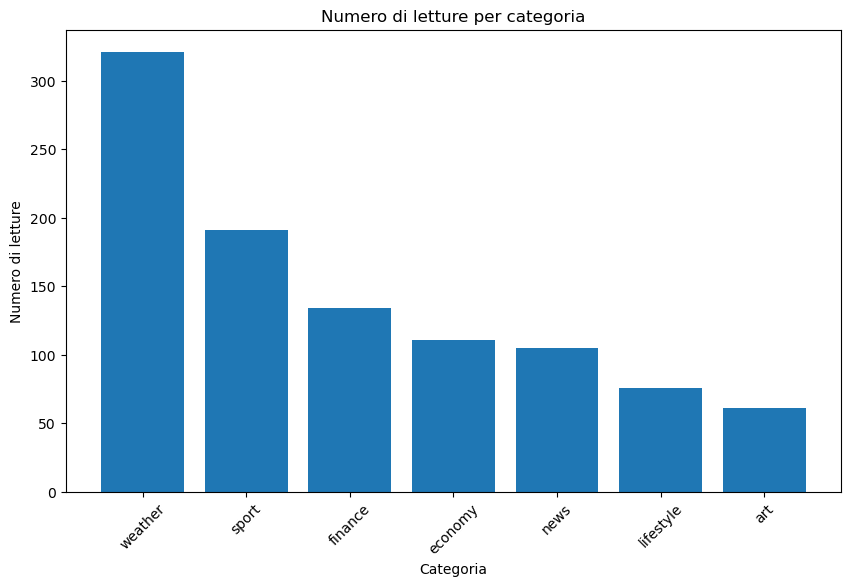

In [11]:
# Creazione di un grafico a barre per visualizzare la distribuzione delle letture per categoria
plt.figure(figsize=(10,6))

# Creazione del grafico a barre per visualizzare le letture per categoria
plt.bar(category_reads['category'], category_reads['reads'])

# Rotazione delle etichette sull'asse X per migliorare la leggibilità
plt.xticks(rotation=45)

# Titolo del grafico
plt.title("Numero di letture per categoria")

# Etichetta asse X
plt.xlabel("Categoria")

# Etichetta asse y
plt.ylabel("Numero di letture")

# visualizzazione del  grafico
plt.show()

Da questa analisi emerge che la categoria più letta è weather, con un numero di letture nettamente superiore rispetto alle altre categorie.

Seguono sport e finance, mentre le categorie meno consultate risultano essere art e lifestyle.

Questa distribuzione suggerisce un forte interesse degli utenti verso contenuti utili, come le previsioni meteo, e verso contenuti informativi, come sport e finanza. Al contrario, le altre categorie risultano meno attrattive.

Questi risultati permettono di ipotizzare che, a livello strategico, potrebbe essere vantaggioso aumentare la produzione di contenuti inerenti alle categorie principali, in quanto maggiormente apprezzate dagli utenti.

In [12]:
# Creazione di una nuova colonna con il mese della lettura
df['read_month'] = df['read_date'].dt.to_period('M')

# Calcolo del numero di letture per mese
monthly_reads = df.groupby('read_month').size().reset_index(name='reads')

# Conversione del mese in formato data per la visualizzazione
monthly_reads['read_month'] = monthly_reads['read_month'].dt.to_timestamp()

# Controllo il risultato
monthly_reads.head()

,read_month,reads
0,2021-01-01,7
1,2021-02-01,11
2,2021-03-01,8
3,2021-04-01,3
4,2021-05-01,2


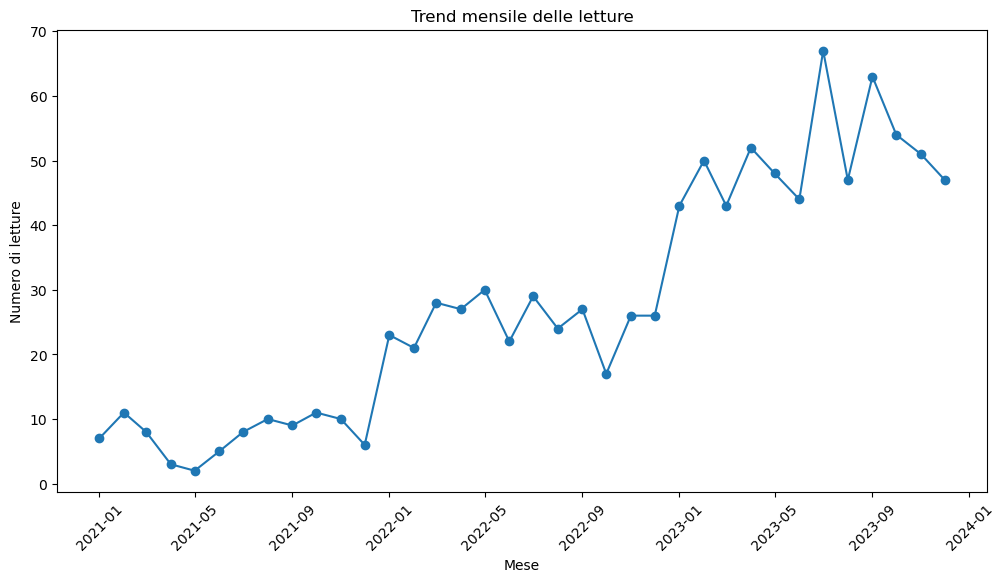

In [13]:
# Creazione del grafico temporale delle letture mensili
plt.figure(figsize=(12,6))
plt.plot(monthly_reads['read_month'], monthly_reads['reads'], marker='o')

# Titolo e label del grafico
plt.title("Trend mensile delle letture")
plt.xlabel("Mese")
plt.ylabel("Numero di letture")

# Rotazione delle date per migliorare la leggibilità
plt.xticks(rotation=45)

# Visualizzazione del grafico
plt.show()

Dall’analisi del trend mensile emerge una crescita progressiva del numero di letture nel tempo.

Nel 2021 il livello di attività risulta contenuto, mentre nel corso del 2022 si osserva un incremento graduale. A partire dal 2023 si registra una crescita più marcata, con un numero di letture significativamente superiore rispetto agli anni precedenti.

Sono inoltre presenti alcuni picchi di lettura, che potrebbero essere legati alla pubblicazione di contenuti particolarmente rilevanti o a eventi specifici.

Nel complesso, il trend evidenzia un aumento dell’engagement degli utenti nel tempo, suggerendo una crescita della piattaforma e un maggiore interesse verso i contenuti proposti.

In [14]:
# Calcolo del numero di letture per ogni utente
user_reads = df.groupby('user_uuid').size().reset_index(name='reads')

user_reads.head()

,user_uuid,reads
0,1,2
1,2,6
2,3,1
3,4,2
4,5,4


In [15]:
# Distribuzione del numero di letture per utente
user_reads['reads'].describe()

count    242.000000
mean       4.128099
std        2.021697
min        1.000000
25%        3.000000
50%        4.000000
75%        5.000000
max       12.000000
Name: reads, dtype: float64

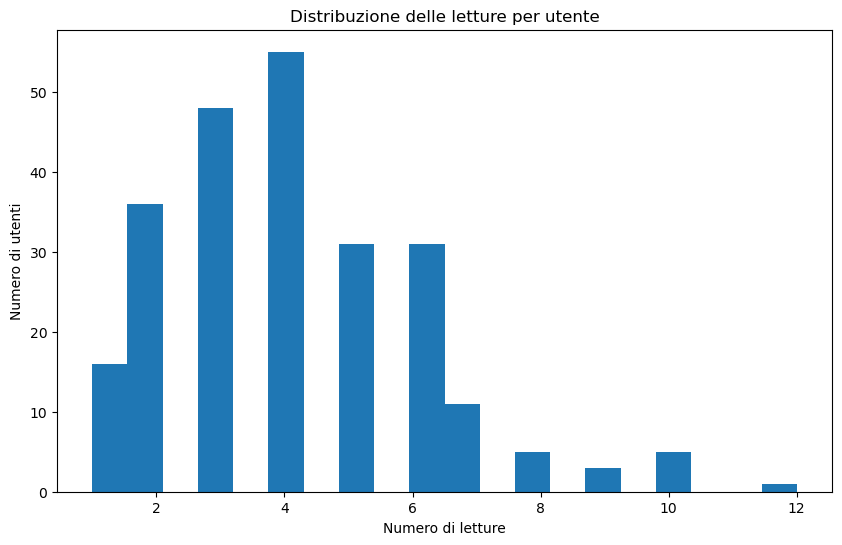

In [16]:
# Imposto la dimensione del grafico 
plt.figure(figsize=(10,6))

# Crea un istogramma per mostrare la distribuzione del numero di letture per utente
plt.hist(user_reads['reads'], bins=20)

# Aggiungo il titolo al grafico
plt.title("Distribuzione delle letture per utente")

# Etichetta dell'asse X 
plt.xlabel("Numero di letture")

# Etichetta dell'asse Y 
plt.ylabel("Numero di utenti")

# Mostro il grafico
plt.show()

Dal grafico si vede che la maggior parte degli utenti legge pochi articoli, principalmente tra 2 e 5.
Sono presenti anche alcuni utenti più attivi, ma rappresentano una minoranza.
Nel complesso, il comportamento generale sembra essere quello di utenti poco o moderatamente attivi.

In [17]:
# Funzione per classificare gli utenti in base al numero di letture
def classify_user(x):
    if x <= 2:
        return "Occasionale"
    elif x <= 5:
        return "Moderato"
    else:
        return "Fedele"

# Applichiamo la funzione al dataset
user_reads['user_type'] = user_reads['reads'].apply(classify_user)

In [18]:
# Conta quanti utenti ci sono in ogni categoria
user_types = user_reads['user_type'].value_counts()

user_types

user_type
Moderato       134
Fedele          56
Occasionale     52
Name: count, dtype: int64

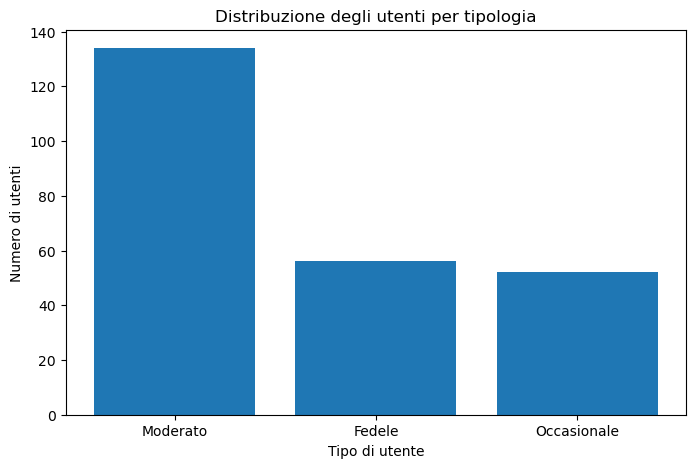

In [19]:
# Creo una figura impostando la dimensione del grafico
plt.figure(figsize=(8,5))

# Creo un grafico a barre con le tipologie di utenti e il loro numero
plt.bar(user_types.index, user_types.values)

# Aggiungo il titolo al grafico
plt.title("Distribuzione degli utenti per tipologia")

# Aggiungo il nome dell'asse X
plt.xlabel("Tipo di utente")

# Aggiungo il nome dell'asse Y
plt.ylabel("Numero di utenti")

# Mostro il grafico
plt.show()

Dal grafico si vede che la maggior parte degli utenti è di tipo moderato, seguita da una quota più ridotta di utenti fedeli e occasionali.

Questo indica che molti utenti utilizzano la piattaforma con una certa frequenza, ma senza essere estremamente attivi. Allo stesso tempo, è presente anche un buon numero di utenti fedeli, che mostrano un livello di coinvolgimento più alto.

Questi risultati suggeriscono che potrebbe essere utile lavorare sia sulla fidelizzazione degli utenti moderati, sia sull’attivazione degli utenti occasionali, per aumentare il livello complessivo di engagement.

Inizio fase di **Cluster analysis**:

In [20]:
# Unione del dataset originale con la tipologia di utente
df_cluster = df.merge(user_reads[['user_uuid', 'user_type']], on='user_uuid', how='left')

In [21]:
# Conteggio delle letture per categoria e tipo di utente
category_user = df_cluster.groupby(['user_type', 'category']).size().reset_index(name='reads')

category_user.head()

,user_type,category,reads
0,Fedele,art,26
1,Fedele,economy,52
2,Fedele,finance,49
3,Fedele,lifestyle,30
4,Fedele,news,34


In [22]:
# Creazione di una tabella pivot
pivot_table = category_user.pivot(index='category', columns='user_type', values='reads')

pivot_table

user_type,Fedele,Moderato,Occasionale
category,,,
art,26,31,4
economy,52,52,7
finance,49,73,12
lifestyle,30,40,6
news,34,59,12
sport,71,102,18
weather,130,162,29


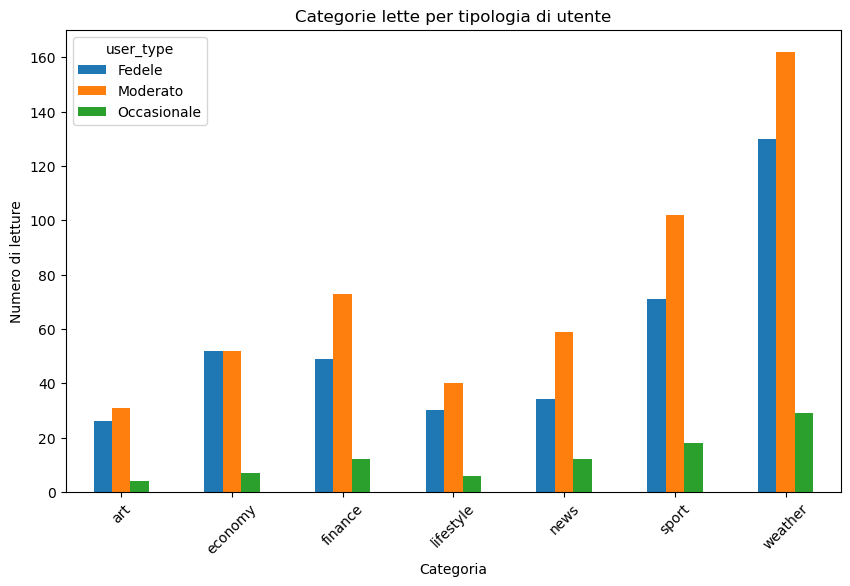

In [23]:
# Creo un grafico a barre partendo dalla tabella pivot
pivot_table.plot(kind='bar', figsize=(10,6))

# Aggiungo il titolo al grafico
plt.title("Categorie lette per tipologia di utente")

# Etichetta dell'asse X 
plt.xlabel("Categoria")

# Etichetta dell'asse Y 
plt.ylabel("Numero di letture")

# Ruoto le etichette sull'asse X per renderle più leggibili
plt.xticks(rotation=45)

# Mostro il grafico
plt.show()

Dal grafico si vede che tutti i tipi di utenti tendono a leggere soprattutto le stesse categorie, in particolare weather, sport e finance.

Gli utenti moderati e fedeli mostrano un comportamento abbastanza simile, ma i fedeli hanno un numero di letture più alto in generale.

Gli utenti occasionali invece leggono molto meno, ma mantengono comunque preferenze simili agli altri.

Questo indica che le differenze tra gli utenti non sono tanto nei contenuti letti, ma nel livello di attività.

A partire dall’analisi dei comportamenti degli utenti, sono state individuate tre principali tipologie di utenti (personas):

- Il “Meteo-dipendente”: utenti molto attivi e altamente coinvolti, che consultano frequentemente la piattaforma.
- L’“Informato Moderato”: utenti con un livello di attività medio, che utilizzano la piattaforma con regolarità.
- Il “Mordi e Fuggi”: utenti occasionali, con un basso livello di interazione.

Questa segmentazione permette di comprendere meglio i diversi comportamenti e supporta la definizione di strategie mirate per aumentare l’engagement.

In [24]:
# Creiamo un dataset aggregato per utente
user_features = df.groupby('user_uuid').agg({'article_id': 'count', 'category': 'nunique'}).reset_index()

# Rinominiamo le colonne per renderle più chiare
user_features.columns = ['user_uuid', 'total_reads', 'unique_categories']

# Mostriamo le prime righe del dataset per controllare che sia corretto
user_features.head()

,user_uuid,total_reads,unique_categories
0,1,2,1
1,2,6,5
2,3,1,1
3,4,2,2
4,5,4,3


In [25]:
# Selezione delle variabili
X = user_features[['total_reads', 'unique_categories']]

# Creo il modello KMeans con 3 cluster
kmeans = KMeans(n_clusters=3, random_state=42)

# Applico il modello ai dati e assegno a ogni utente un cluster
user_features['cluster'] = kmeans.fit_predict(X)

c:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


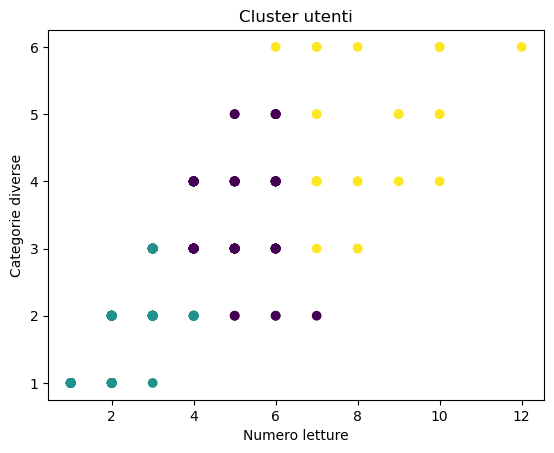

In [26]:
# Creo uno scatter plot 
plt.scatter(user_features['total_reads'], user_features['unique_categories'], c=user_features['cluster'])

# Etichetta dell'asse X
plt.xlabel("Numero letture")

# Etichetta dell'asse Y
plt.ylabel("Categorie diverse")

# Titolo del grafico
plt.title("Cluster utenti")

# Mostro il grafico
plt.show()

Per approfondire l’analisi, è stato applicato un algoritmo di clustering (K-means) utilizzando come variabili il numero di letture e la varietà di categorie lette per ciascun utente.

Dal grafico emergono tre gruppi distinti di utenti: un primo gruppo con basso livello di attività, un secondo con attività intermedia e un terzo con utenti molto attivi e interessati a diverse categorie.

Questi risultati risultano coerenti con la segmentazione precedente (Occasionali, Moderati e Fedeli), confermando la validità dell’analisi.

In [27]:
# creo una colonna read_mont per facilitare la successiva analisi con Tableau
df_cluster['read_month'] = df_cluster['read_date'].dt.to_period('M').astype(str)

In [28]:
# Creazione mapping tra tipo utente e persona
mapping = {
    "Occasionale": "Mordi e Fuggi",
    "Moderato": "Esploratore",
    "Fedele": "Super Lettore"
}

# Creazione nuova colonna persona
df_cluster['persona'] = df_cluster['user_type'].map(mapping)

In [30]:
# Esporto il dataset finale in formato CSV per utilizzarlo in Tableau
# index=False serve per non salvare l'indice del DataFrame nel file
df_cluster.to_csv("dataset_tableau.csv", index=False)

### CONCLUSIONE:

Dall’analisi emerge che le categorie più lette sono weather e sport, quindi potrebbe essere utile aumentare la produzione di contenuti su questi temi, in quanto risultano i più attrattivi per gli utenti.

Inoltre, il trend temporale mostra una crescita nel numero di letture nel tempo, segnale positivo dell’aumento dell’engagement della piattaforma.

Gli utenti moderati rappresentano la maggioranza, quindi lavorare sulla loro fidelizzazione potrebbe permettere di aumentare il numero di utenti fedeli.

Allo stesso tempo, gli utenti occasionali potrebbero essere coinvolti maggiormente attraverso contenuti semplici, immediati e facilmente accessibili.

In generale, la strategia dovrebbe puntare ad aumentare il coinvolgimento degli utenti e migliorare la frequenza di utilizzo della piattaforma, valorizzando i contenuti più performanti.